# DUSt3R & MASt3R: Structure from Motion with Deep Learning

This is a tutorial on the new family of *feed-forward 3D reconstruction* models —
DUSt3R, MASt3R, and their relatives (VGGT, Depth Anything, MapAnything, ...).

It has two parts:

1. **Concepts** — the paper landscape, a recommended reading order, and a precise
   explanation of how DUSt3R/MASt3R actually work (including corrections of some
   common misconceptions).
2. **Hands-on** — give MASt3R two (or more) images and get: pointmaps, depth maps,
   dense matches, camera intrinsics, relative pose, and a colored 3D point cloud
   exported as PLY.

**Requirements:** the `mast3r` repo cloned (with submodules) under
`third_party/mast3r`, PyTorch with CUDA, and `pip install roma einops trimesh rerun-sdk`.
The checkpoint (~2.5 GB) auto-downloads from Hugging Face
(`naver/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric`) into `~/.cache/huggingface/`
on first use. You can also download checkpoints manually from
<https://download.europe.naverlabs.com/ComputerVision/MASt3R/> (or `.../DUSt3R/`).


## 1. The paper landscape

There are **two separate lineages** that people often mix up, plus a third from
Oxford's Visual Geometry Group (VGG), and they all start converging around 2025:

```text
Monocular depth  -  single image -> depth map
    MiDaS / DPT (2020-21)
      +-- Depth Anything V1 (CVPR'24)
            +-- Depth Anything V2 (NeurIPS'24)
                  +-- Depth Anything 3 (2025)          [also fed by VGGT]

Pointmap regression  -  Naver: image pairs -> 3D points
    CroCo pretraining (NeurIPS'22)
      +-- DUSt3R (CVPR'24)
            +-- MASt3R (ECCV'24)
            |     +-- MASt3R-SfM (2024)
            |     +-- MASt3R-SLAM (CVPR'25)
            +-- Spann3R / Fast3R / MUSt3R / CUT3R   (multi-view & streaming, 2024-25)
            +-- MonST3R (dynamic scenes, ICLR'25)

Multi-view feed-forward  -  VGG Oxford: N images -> cameras + depth + points
    VGGSfM (CVPR'24)
      +-- VGGT (CVPR'25, best paper)
            +-- VGGT-SLAM (2025)

Cross-links between the lineages
    DUSt3R ....... paradigm ......> VGGT
    MASt3R + VGGT ...............> MapAnything (Meta, 2025)
    Depth Anything V2 + VGGT ....> Depth Anything 3 (2025)
```

### The three lineages in one sentence each

| Lineage | Input → Output | Key idea |
|---|---|---|
| **Depth Anything** (V1/V2) | 1 image → per-pixel **depth** (up to scale) | Scale up monocular depth with a data engine (62M images), distillation |
| **DUSt3R → MASt3R** | 2 images → per-pixel **3D points** (pointmaps) | Replace the whole SfM pipeline (features → E/F matrix → triangulation) with direct regression |
| **VGGSfM → VGGT** | N images → cameras + depth + points + tracks | One feed-forward transformer for the entire scene, no pairwise stitching |

**How is Depth Anything related to DUSt3R?** It is *not* part of the DUSt3R
pipeline — it's an orthogonal, single-view tool. DUSt3R predicts its own geometry;
it does not call a monocular depth network. **MapAnything** (2025), on the other
hand, *is* the direct continuation of the DUSt3R/VGGT line: one feed-forward model,
up to thousands of views, metric scale, optionally consuming intrinsics/poses/depth
if you have them. **Depth Anything 3** (2025) is where the monocular lineage also
becomes multi-view — the two branches effectively merge.

### Recommended reading order

1. **DUSt3R** (CVPR 2024) — *the* paradigm shift; read this thoroughly. Everything
   else is a delta on it. Sections to internalize: pointmap definition, the
   confidence-weighted regression loss, and §3.3 "Downstream tasks" (how
   intrinsics/pose/depth all fall out of pointmaps).
2. **MASt3R** (ECCV 2024) — adds a descriptor head for *matching* + metric scale.
3. **MASt3R-SfM** (2024) — how to scale the pairwise idea to full SfM
   (coarse 3D alignment, then 2D reprojection refinement).
4. **VGGT** (CVPR 2025) — drops the pairwise design entirely: one transformer,
   N views, alternating frame-wise / global attention.
5. **Depth Anything V2** (NeurIPS 2024) — read in parallel any time; it's the
   monocular branch, useful to understand scale ambiguity and data engines.
6. Then by interest: **MASt3R-SLAM** (real-time SLAM), **MonST3R** (dynamic
   scenes), **CUT3R/Spann3R/Fast3R** (streaming / many views),
   **MapAnything** & **Depth Anything 3** (the 2025 convergence).

**Optional background:** **CroCo** (NeurIPS 2022) — the cross-view completion
pretraining that made DUSt3R possible. Skim it only if you wonder *why* a ViT can
learn geometry this way. You do **not** need to go further back than this; your
classical SfM knowledge (epipolar geometry, PnP, bundle adjustment, ICP) is the
only other prerequisite, and this family exists precisely to replace it.

### The 2026 role inversion: feed-forward front-end, classical back-end

*(Written July 2026 — where the field actually went after the diagram above.)*

Four eras, one axis: **where does multi-view consistency live?**

| Era | Front-end | Back-end | Consistency lives in |
|---|---|---|---|
| 2016–2020 | SIFT | incremental SfM (COLMAP) | bundle adjustment |
| 2020–2023 | learned matching (SuperGlue, LoFTR, hloc) | COLMAP | bundle adjustment |
| 2024 | pairwise pointmaps (DUSt3R / MASt3R) | global alignment (MASt3R-SfM) | **pairwise stitching** ← the weak link |
| 2025–26 | multi-view transformer (VGGT → VGGT-Ω) | *optional* BA polish | **attention, one forward pass** |

The synthesis is a **role inversion, not a replacement**. Bundle adjustment moves
from the *center* of the pipeline (the engine that makes everything consistent)
to the *edge* (a cheap verifier/refiner on an already-consistent feed-forward
initialization). VGGT's own `demo_colmap.py --use_ba` is that architecture in
~200 lines: feed-forward poses + depth → COLMAP binary format → triangulation +
one global BA.

**The COLMAP author is the strongest evidence.** Johannes Schönberger (COLMAP;
now Meta Zurich, Spatial AI) is building both sides *and* the bridge, 2025–26:

- **VGGT-Ω** (CVPR 2026, co-author) — 1B-param feed-forward model; the paper's
  core claim is that reconstruction quality *"scales predictably with model and
  data size"* — the bitter-lesson argument.
- **"Global Structure-from-Motion Meets Feedforward Reconstruction"** (CVPR
  2026, with Linfei Pan of GLOMAP and Marc Pollefeys) — literally the hybrid:
  feed-forward front-end, global-SfM back-end.
- **MapAnything** (3DV 2026) — universal feed-forward metric reconstruction.
- **MP-SfM** (CVPR 2025) — monocular priors injected *into* classical SfM.
- **"Fixing the RANSAC Stopping Criterion"** (2025) — still pure classical
  geometry. COLMAP itself remains actively maintained.

#### Why gluing pairwise MASt3R into COLMAP is *not* the hybrid to build

Tempting idea: MASt3R front-end for robustness, COLMAP BA for scale and
bad-pose rejection. Three structural problems, none fixable by engineering:

1. **Pairwise inference reintroduces the stitching problem.** Each pair predicts
   pointmaps in *its own* canonical frame at *its own* scale. Making $N$ frames
   consistent is a nonlinear optimization over per-pair scales and poses — BA
   deleted out the front door, back through the window.
2. **No marginalization.** MASt3R-SLAM keeps every keyframe's dense pointmap
   alive in the global optimization; nothing is summarized away à la
   sliding-window VIO, so memory grows without bound (≈2 minutes of video in
   practice).
3. **$O(N^2)$ forward passes** with a heavy per-pair model — the same disease as
   exhaustive matching, at higher cost per pair.

The multi-view transformer dissolves all three at once: frames exchange
information through attention *inside* the network, poses emerge in **one shared
canonical frame**, one forward pass. VGGT-Ω's register attention exists
precisely to tame the memory of that global attention (~30% of VGGT's
footprint).

#### Long video: submapping and streaming, not per-image poses into BA

The trend's answer to "MASt3R-SLAM has no sliding window":

- **VGGT-SLAM** (2025) — chunk the video into submaps, one forward pass per
  chunk, align submaps with a lightweight pose graph. Memory bounded by chunk
  size, not video length.
- **Streaming/recurrent** — CUT3R (persistent state), Spann3R, MUSt3R, SLAM3R:
  fixed-size memory updated per frame.

Practical chunked recipe (numbers measured with VGGT-Ω 1B, fp32 weights + bf16
autocast, RTX 3090 24 GB):

| resolution | 50 frames | 100 | 150 | 200 |
|---|---|---|---|---|
| 512 | 11.0 GB / 14 s | 17.8 GB / 47 s | OOM | — |
| 384 | 8.0 GB / 5.6 s | 11.8 GB / 17 s | 15.6 GB / 34 s | OOM |
| 256 | 5.9 GB / 1.9 s | 7.6 GB / 4.5 s | 9.2 GB / 8.4 s | 10.9 GB / 13.5 s |

(The README's "43 GB for 500 frames" is 624×416 on an 80 GB A100 — on 24 GB the
native-512 ceiling is ~100 frames.) So: chunks of ~100 frames @ 512 with ~10
overlapping frames → Sim(3)-align consecutive chunks on the overlap (Umeyama) →
hand all poses to pycolmap/GLOMAP for triangulation + one global BA. The BA
reprojection filter also restores what feed-forward models lack: the ability to
*reject* an image — the model always emits a pose, it cannot decline.

#### Licensing decides more than benchmarks

| | Code | Weights | Commercial use |
|---|---|---|---|
| DUSt3R / MASt3R (Naver) | CC BY-NC-SA 4.0 | CC BY-NC-SA 4.0 | ❌ non-commercial **and** viral |
| VGGT-Ω | FAIR Noncommercial Research License v1 | same, gated | ❌ — the license covers *"any outputs or results"*, i.e. your reconstructions too |
| VGGT `VGGT-1B-Commercial` | permissive | commercial, gated | ✅ the only licensed door in the family |
| COLMAP / GLOMAP | BSD | — | ✅ |

For research and competitions any of them work; for a product, the classical
back-end is BSD and the only commercial feed-forward checkpoint is
`VGGT-1B-Commercial`.

### VGGT-SLAM: how loop closure works at submap level

*(Specifics from [arXiv:2505.12549](https://arxiv.org/abs/2505.12549), Maggio,
Lim & Carlone; SL(4) factors landed in GTSAM,
[blog](https://gtsam.org/2026/06/24/vggt-slam.html).)*

One line: **graph SLAM at submap granularity**. Submaps are $w=32$ frames
(8/16/32 tested; VGGT caps at ~60 frames on a 24 GB RTX 3090), each sharing
**one frame** with the previous submap. Internal submap geometry is frozen —
the graph only moves whole submaps.

A pose graph cannot *find* a loop; three ingredients make closure work, the
same three as ORB-SLAM, one level up:

1. **Detection is appearance, not geometry.** Every keyframe gets a **SALAD**
   descriptor (DINOv2-based place recognition — the modern DBoW). New frames
   are compared by L2 similarity against previous submaps' keyframes; matches
   above $\tau_{desc}=0.8$ propose a loop.
2. **The loop constraint is free 3D↔3D correspondences.** The retrieved *old*
   frame is **inserted into the new submap's VGGT forward pass** (the
   $w_{loop}=1$ slot). That frame now has dense per-pixel 3D in *both*
   submaps → thousands of 3D–3D correspondences with no feature matching. The
   relative transform is estimated by RANSAC (5-point solver, 300 iterations,
   threshold 0.01) — *identically* to how consecutive submaps are aligned
   through their shared frame. One aligner for odometry edges and loop edges.
3. **A tiny graph of rigid submaps.** Nodes: one absolute homography $H_i$
   **per submap** (not per camera). Factors: the sequential chain + loop
   edges. A loop edge says "composition around this cycle = identity"; the
   accumulated chain disagrees; Levenberg–Marquardt distributes the error
   around the cycle. Moving a few dozen submap transforms snaps thousands of
   cameras and millions of points at once.

**Why SL(4), not Sim(3) — the paper's actual contribution.** Monocular
ORB-SLAM closes loops on Sim(3) because monocular drift includes scale
(7 DoF). VGGT-SLAM escalates the same argument: by the projective
reconstruction theorem, an *uncalibrated* reconstruction is only defined up to
a **15-DoF homography of $\mathbb{P}^3$** — each submap can sit in a different
*projective* frame, which Sim(3)'s 7 DoF cannot map onto another. So the graph
lives on SL(4), with Sim(3) as the special case when intrinsics are trusted:

$$\text{SE}(3) \;\xrightarrow{\text{scale drift}}\; \text{Sim}(3)
\;\xrightarrow{\text{projective drift}}\; \text{SL}(4)$$

Known weakness, also classical: full homography estimation is **degenerate for
planar scenes** (the H/E degeneracy reappearing). And two honest limits:
intra-submap drift is frozen forever (no BA inside a submap), and a revisit
that looks too different for SALAD (viewpoint/lighting) never fires.

### Persistent state: the learned filter

One line: **CUT3R is an EKF whose state vector is learned.**
([CUT3R](https://github.com/CUT3R/CUT3R), "Continuous 3D Perception Model with
Persistent State", CVPR'25.)

Sliding-window VIO never keeps the past — it **marginalizes** old poses and
landmarks into a fixed-size prior. "Persistent state" is the learned
generalization: a **fixed set of learned tokens** that *is* the map,
compressed into a constant-size latent buffer. Per frame, two cross-attentions:

1. **Frame reads state** — the new image's tokens attend to the state and the
   decoder emits the frame's pointmap **directly in the world frame** plus its
   pose. Frame 500 localizes against everything since frame 0 with *no
   matching, retrieval, or optimization* — "where am I relative to the map" is
   one attention pass.
2. **State reads frame** — state tokens attend back and absorb the new
   geometry.

Constant memory and compute per frame → arbitrary video length (exactly what
MASt3R-SLAM lacks). The state is a real scene representation, not a buffer:
CUT3R can be queried with a *virtual* camera (raymap) and predicts geometry
for views it never saw.

The streaming variants differ only in what the "state" physically is:

| Model | State | Growth |
|---|---|---|
| CUT3R | fixed set of learned tokens, updated by cross-attention | constant |
| Spann3R | external key–value feature bank ("spatial memory") | bounded, evicted |
| StreamVGGT | causal attention's KV-cache of past frames | linear, no recompute |

**The punchline that connects the two sections.** The recurrent state fails
exactly like an EKF: fixed capacity means **forgetting** (revisit a room ten
minutes later and those tokens may be overwritten), and updates are
**irreversible** — a filter that already integrated drift has no way to
redistribute error around a cycle it never knew was a cycle. That is *why*
these models have no loop closure, and why VGGT-SLAM's submap graph exists:
it is the **smoother** to CUT3R's **filter**.

| | Streaming (CUT3R et al.) | Submap graph (VGGT-SLAM) |
|---|---|---|
| classical analogue | filtering (EKF / marginalizing VIO) | smoothing / graph SLAM |
| memory | constant | grows with submaps (slowly) |
| latency | per-frame, real-time | chunky (one submap at a time) |
| loop closure | none — can't correct the past | yes — cycle error redistributed |
| forgetting | yes, capacity-bound | no, submaps persist |

Thirty years of SLAM — filter vs smoother, Sim(3) loop closure, place
recognition as a separate module — re-derived by the feed-forward crowd.

## 2. How DUSt3R actually works

### 2.1 The pointmap

For an image of size $W \times H$, a **pointmap** $X \in \mathbb{R}^{W \times H \times 3}$
assigns to *every pixel* $(u,v)$ a 3D point $X_{u,v} = (x, y, z)$.

This is strictly more than a depth map: a depth map gives one scalar $z$ per pixel
and needs known intrinsics $K$ to become 3D points via
$X_{u,v} = z_{u,v} \cdot K^{-1} (u, v, 1)^\top$.
A pointmap *is already* the 3D points — intrinsics are implicitly baked in, and, as
we'll see below, can be recovered from it.

### 2.2 The architecture — and the biggest misconception

A common wrong mental model (I had it too):

> ❌ "The network processes each image *independently*, predicts a pointmap for
> each in its own frame, and then you align the two point clouds with something
> like ICP."

That is **not** what happens. DUSt3R takes the **pair jointly**:

```
image 1 ──► ViT encoder ──► tokens₁ ──► decoder 1 ──► head ──► X¹·¹, C¹
                              │  ▲
                 cross-attention (every block, both directions)
                              ▼  │
image 2 ──► ViT encoder ──► tokens₂ ──► decoder 2 ──► head ──► X²·¹, C²
```

- The two images go through a **shared ViT encoder** separately.
- Then two **decoders exchange information via cross-attention at every block**.
  Each decoder constantly "sees" the other view. This is where correspondence
  is implicitly established — inside the network.
- The output heads regress two pointmaps **and per-pixel confidence maps** $C$:
  - $X^{1,1}$ — pointmap of image 1, expressed in **camera 1's frame**
  - $X^{2,1}$ — pointmap of image 2, **also expressed in camera 1's frame**

### 2.3 From tokens to $(x,y,z)$: what the head actually regresses

This is the step that feels like magic, so let's follow one pixel all the way
through. Concrete shapes are for the checkpoint used in §4
(`MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric`, whose `config.json` gives
encoder 24 blocks × 1024-d, decoder 12 blocks × 768-d, `output_mode:
"pts3d+desc24"`, patch size 16), on a 512×384 input:

| stage | tensor | shape |
|---|---|---|
| input image, normalized | $I$ | $3 \times 384 \times 512$ |
| patchify $16\times16$ + RoPE positional encoding | tokens | $768 \times 1024$  (768 = 24×32 patches) |
| shared ViT-L encoder, 24 blocks (**same weights for both images**) | $F^1, F^2$ | $768 \times 1024$ each |
| decoder, 12 blocks, self-attn **+ cross-attn to the other branch** | $G^1, G^2$ | $768 \times 768$ each |
| DPT head, reading 4 levels (encoder output + decoder blocks 6, 9, 12) | raw pixelwise map | $\mathbf{4} \times 384 \times 512$ |
| MLP head on `concat(enc, dec)` (1792-d) → `pixel_shuffle(16)` | raw descriptor map | $\mathbf{25} \times 384 \times 512$ |

So per pixel the head emits **29 raw numbers**, sliced like this
(`mast3r/catmlp_dpt_head.py::postprocess`):

```
[0:3]   raw 3-vector   → pts3d
[3]     raw scalar     → conf
[4:28]  raw 24-vector  → desc        (MASt3R only)
[28]    raw scalar     → desc_conf   (MASt3R only)
```

**The raw 3-vector is not the point.** It is decoded by `reg_dense_depth` with
`depth_mode=('exp', -inf, inf)`, which splits it into a direction and a range
(`dust3r/heads/postprocess.py`):

$$ d = \lVert r \rVert, \qquad \hat u = \frac{r}{d}, \qquad X = \hat u \cdot \big(e^{d}-1\big) $$

- $\hat u$ is a **unit ray direction expressed in camera 1's frame** — the *bearing*
  of the point.
- $e^{d}-1$ (`torch.expm1`) is the **range along that ray**, in metres for this
  metric checkpoint. `expm1` is strictly positive and unbounded: fine resolution
  near the camera, room for far points to run off to infinity, and it can never
  produce a negative (behind-the-camera) range.

Worked example — say the head emits $r = (0.10,\, -0.20,\, 1.40)$ at some pixel:

$$d = 1.4177,\quad \hat u = (0.0705,\, -0.1411,\, 0.9875),\quad e^{d}-1 = 3.1275$$
$$\Rightarrow\ X = (0.221,\ -0.441,\ 3.088)\ \text{m}$$

i.e. 3.09 m in front of camera 1, slightly to the left and above the optical axis
(remember: $x$ right, $y$ **down**, $z$ forward — OpenCV convention).

Confidence is decoded by `reg_dense_conf` with `conf_mode=('exp', 1, ∞)`:
$C = 1 + e^{c_{\text{raw}}}$, so **$C \ge 1$ always** — which is why thresholds in
this family's code look like `conf > 1.5`, not `conf > 0.5`. Descriptors go through
`reg_desc(mode='norm')`, i.e. they are **L2-normalized to the unit sphere**, so a
dot product between two descriptors is a cosine similarity (§3).

**Where does "camera 1's frame" come from, mechanically?** Nothing in the
architecture enforces it. It comes **entirely from the training targets**: the
ground-truth pointmap of view 2 is built as
$\bar X^{2,1}_{u,v} = T_{1\leftarrow 2}\, \big(D^2_{u,v} K_2^{-1}(u,v,1)^\top\big)$
from GT depth and GT relative pose, and the regression loss (§2.5) punishes any
deviation from it. The convention is *learned*, not imposed. Two consequences:

- The model is **asymmetric** — hence the class name `AsymmetricMASt3R`, and
  `downstream_head1` / `downstream_head2` being separate weights. Branch 1 learns
  "output points in *my* frame"; branch 2 learns "output points in *the other*
  branch's frame". Swap the image order and you get a genuinely different result
  ($X^{2,2}, X^{1,2}$) — which §4.3 exploits.
- There is **no geometric constraint at inference**: no triangulation, no epipolar
  check, nothing that *guarantees* the two pointmaps are mutually consistent.
  Consistency is a statistical property the network was trained to have. That is
  precisely why the confidence channel exists, and why global alignment (§2.7)
  re-optimizes everything as soon as you have more than two views.

**So where does $z$ actually come from?** Two sources, silently blended:

1. **Cross-view parallax** — the cross-attention decoder compares the two views, so
   for a well-textured pixel with a healthy baseline this is effectively *learned
   triangulation*.
2. **Monocular priors** — object size, perspective, vanishing points, texture
   gradients, shading; learned during CroCo cross-view-completion pretraining and
   from millions of GT-depth images.

When the baseline is tiny or the region is textureless, (2) quietly takes over.
That is simultaneously the strength of the whole family (it always outputs
*something* geometrically plausible, where COLMAP would just fail) and its
weakness (it can be confidently wrong, and no residual will tell you).

### 2.4 The "canonical frame" is just camera 1

The reference frame is **not** an abstract learned world frame — it is simply the
camera frame of the *first image of the pair*. That convention is what makes the
output immediately useful:

**Both point clouds already live in the same coordinate system.** There is no
ICP, no Procrustes, no rotation search *within a pair* — the cross-attention
decoder already did the "registration" implicitly.

What *is* true (and matters for multi-view): every **pair** has its own reference
frame (camera 1 of *that pair*), and its own arbitrary scale. Pair (1,2) lives in
camera 1's frame; pair (3,4) lives in camera 3's frame. Stitching many pairs into
one world frame is a separate step called **global alignment** (§2.7).

### 2.5 Training loss

Simple confidence-weighted 3D regression. For each valid pixel $i$ in view $v$:

$$\mathcal{L} = \sum_{v \in \{1,2\}} \sum_{i} C_i^v \left\| \tfrac{1}{s} X_i^{v,1} - \tfrac{1}{\bar{s}} \bar{X}_i^{v,1} \right\| - \alpha \log C_i^v$$

- $\bar{X}$ is ground truth (from datasets with known depth+pose: Habitat,
  ScanNet++, MegaDepth, ARKitScenes, CO3D, ...).
- $s, \bar{s}$ are scene scale normalizers → predictions are **up to scale**
  (MASt3R later removes $s$-normalization on metric datasets → metric output).
- The confidence weighting is self-supervised: the network learns to say "I'm
  unsure here" (sky, glass, occlusions) and pays $-\alpha \log C$ for the privilege.
- No reprojection loss, no pose loss, no epipolar constraint anywhere.

### 2.6 Everything falls out of the pointmaps

| Quantity | How |
|---|---|
| **Depth map** of image 1 | just the $z$ channel of $X^{1,1}$ |
| **Intrinsics** (focal) | solve $\min_f \sum_i C_i \,\| (u_i,v_i) - f \frac{(x_i,y_i)}{z_i} \|$ — a 1-parameter Weiszfeld iteration on $X^{1,1}$ |
| **Relative pose** | PnP-RANSAC with 3D points $X^{2,1}$ ↔ pixels of image 2 (or Procrustes between $X^{1,1}$ and $X^{1,2}$ from the swapped pair) |
| **Correspondences** | reciprocal nearest neighbors **between the two pointmaps in 3D** (DUSt3R) or in descriptor space (MASt3R, §3) |

### 2.7 Multi-view: global alignment (this is *not* bundle adjustment)

For $N$ images: build a connectivity graph of pairs, run DUSt3R on each pair, then
optimize — for every image $n$ a world pointmap $\chi^n$, and for every pair $e=(n,m)$
a similarity transform $(\sigma_e, P_e)$ — by minimizing **3D distances**:

$$\min_{\chi, P, \sigma} \sum_{e} \sum_{v \in e} \sum_i C_i^{v,e} \left\| \chi_i^v - \sigma_e P_e X_i^{v,e} \right\|$$

Gradient descent, a few hundred iterations, seconds on a GPU. Unlike classical
bundle adjustment there is **no 2D reprojection error** — it aligns clouds directly
in 3D. (MASt3R-SfM later *adds* a 2D reprojection refinement stage after the
coarse 3D alignment, which is one of its main contributions.)

## 3. MASt3R: what it adds on top of DUSt3R

MASt3R = "**M**atching **A**nd **S**tereo **3D** **R**econstruction". Same
encoder/decoder + pointmap heads, plus:

1. **A descriptor head**: per pixel, a $d=24$-dim local feature $D_{u,v}$, trained
   with an InfoNCE contrastive loss on ground-truth correspondences. Matching now
   happens in **descriptor space** (not in 3D-point space as in DUSt3R) — far more
   robust, and it made MASt3R state of the art on the map-free localization
   benchmark.
2. **Fast reciprocal NN matching**: exact mutual-NN search is $O(W^2H^2)$;
   MASt3R's iterative scheme starts from a sparse pixel grid and alternates
   NN-search until convergence to mutual pairs — orders of magnitude faster.
3. **Coarse-to-fine matching** to operate on high-resolution images despite the
   512-px network input.
4. **Metric scale**: trained so pointmaps are in meters (no per-scene scale
   normalization on metric datasets).

> **Misconception to retire:** "DUSt3R matches learned features between the two
> images." In *DUSt3R* correspondences come from mutual nearest neighbors **in 3D
> pointmap space**. Descriptor-based matching is precisely what **MASt3R** added.
> And neither uses epipolar geometry to constrain the search — no F/E matrix,
> no RANSAC over epipolar constraints, anywhere.

**vs classical SfM, side by side:**

| Classical (COLMAP) | DUSt3R/MASt3R |
|---|---|
| Detect keypoints (SIFT) | — (dense, implicit in the network) |
| Match descriptors + ratio test | MASt3R descriptor head + reciprocal NN |
| RANSAC on E/F matrix | — (no epipolar estimation at all) |
| Triangulate sparse points | Pointmaps are dense, regressed directly |
| Incremental registration + PnP | PnP still used, but on dense predicted 3D |
| Bundle adjustment (2D reproj.) | 3D global alignment (+ 2D refinement in MASt3R-SfM) |
| Fails: textureless, low overlap, few views | Works: priors fill in what matching can't |


## 4. Hands-on: two images → 3D

We now run MASt3R on a pair of images and recover, step by step: pointmaps,
depth, confidence, dense matches, focal length, relative camera pose, and a
colored point cloud.

Change `IMG1`/`IMG2` below to try your own images (any resolution — they get
resized to 512 px on the long side).


In [1]:
import sys, os
from pathlib import Path

# --- paths -------------------------------------------------------------
HERE = Path.cwd()                      # docs/visual_odometry
MAST3R_ROOT = HERE / "third_party" / "mast3r"
assert MAST3R_ROOT.exists(), "clone https://github.com/naver/mast3r --recursive into third_party/"
# drop this notebook's own directory from sys.path: our local models/ package
# (regular, has __init__.py) always beats croco's `models` (namespace package),
# no matter the path order -> ModuleNotFoundError: models.dpt_block
sys.path = [p for p in sys.path if Path(p or ".").resolve() != HERE]
sys.path.insert(0, str(MAST3R_ROOT))
sys.path.insert(0, str(MAST3R_ROOT / "dust3r"))
sys.path.insert(0, str(MAST3R_ROOT / "dust3r" / "croco"))

import numpy as np
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

# --- the two input images (swap in your own here) ----------------------
img_dir = MAST3R_ROOT / "assets" / "NLE_tower"
files = sorted(img_dir.iterdir())
IMG1, IMG2 = str(files[0]), str(files[3])
print(Path(IMG1).name, "\n" + Path(IMG2).name)

device: cuda
01D90321-69C8-439F-B0B0-E87E7634741C-83120-000041DAE419D7AE.jpg 
28EDBB63-B9F9-42FB-AC86-4852A33ED71B-83120-000041DAF22407A1.jpg


In [2]:
from mast3r.model import AsymmetricMASt3R

# ~2.5 GB, auto-downloaded to ~/.cache/huggingface on first call
model = AsymmetricMASt3R.from_pretrained(
    "naver/MASt3R_ViTLarge_BaseDecoder_512_catmlpdpt_metric").to(device)
model.eval()
print(f"{sum(p.numel() for p in model.parameters())/1e6:.0f} M parameters")

Warning, cannot find cuda-compiled version of RoPE2D, using a slow pytorch version instead


/home/behnam/anaconda3/envs/PyTorchTutorial/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


689 M parameters


In [3]:
from dust3r.utils.image import load_images
from dust3r.inference import inference

# load_images resizes to 512 on the long side and normalizes
images = load_images([IMG1, IMG2], size=512)

# ONE forward pass on the PAIR (not two independent passes!)
output = inference([tuple(images)], model, device, batch_size=1, verbose=False)

pred1, pred2 = output["pred1"], output["pred2"]
print("pred1:", list(pred1.keys()))
print("pred2:", list(pred2.keys()))

>> Loading a list of 2 images
 - adding /home/behnam/workspace/robotic_notes/docs/visual_odometry/third_party/mast3r/assets/NLE_tower/01D90321-69C8-439F-B0B0-E87E7634741C-83120-000041DAE419D7AE.jpg with resolution 1000x1334 --> 384x512
 - adding /home/behnam/workspace/robotic_notes/docs/visual_odometry/third_party/mast3r/assets/NLE_tower/28EDBB63-B9F9-42FB-AC86-4852A33ED71B-83120-000041DAF22407A1.jpg with resolution 1000x1334 --> 384x512
 (Found 2 images)


/home/behnam/workspace/robotic_notes/docs/visual_odometry/third_party/mast3r/dust3r/dust3r/inference.py:44: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=bool(use_amp)):


pred1: ['pts3d', 'conf', 'desc', 'desc_conf']
pred2: ['conf', 'desc', 'desc_conf', 'pts3d_in_other_view']


/home/behnam/workspace/robotic_notes/docs/visual_odometry/third_party/mast3r/dust3r/dust3r/model.py:206: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/home/behnam/workspace/robotic_notes/docs/visual_odometry/third_party/mast3r/dust3r/dust3r/inference.py:48: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


Look carefully at the output keys — they encode the whole §2.4 story:

- `pred1["pts3d"]` → $X^{1,1}$: pointmap of image 1 **in camera 1's frame**
- `pred2["pts3d_in_other_view"]` → $X^{2,1}$: pointmap of image 2, **also in
  camera 1's frame**. The key name says it explicitly: *in the other view's frame*.
- `conf` → the confidence maps $C$ from the training loss
- `desc`, `desc_conf` → MASt3R's 24-dim matching descriptors (DUSt3R doesn't have these)

Both pointmaps are already registered in one coordinate system — no ICP needed.

pointmap shapes: (512, 384, 3) (512, 384, 3)


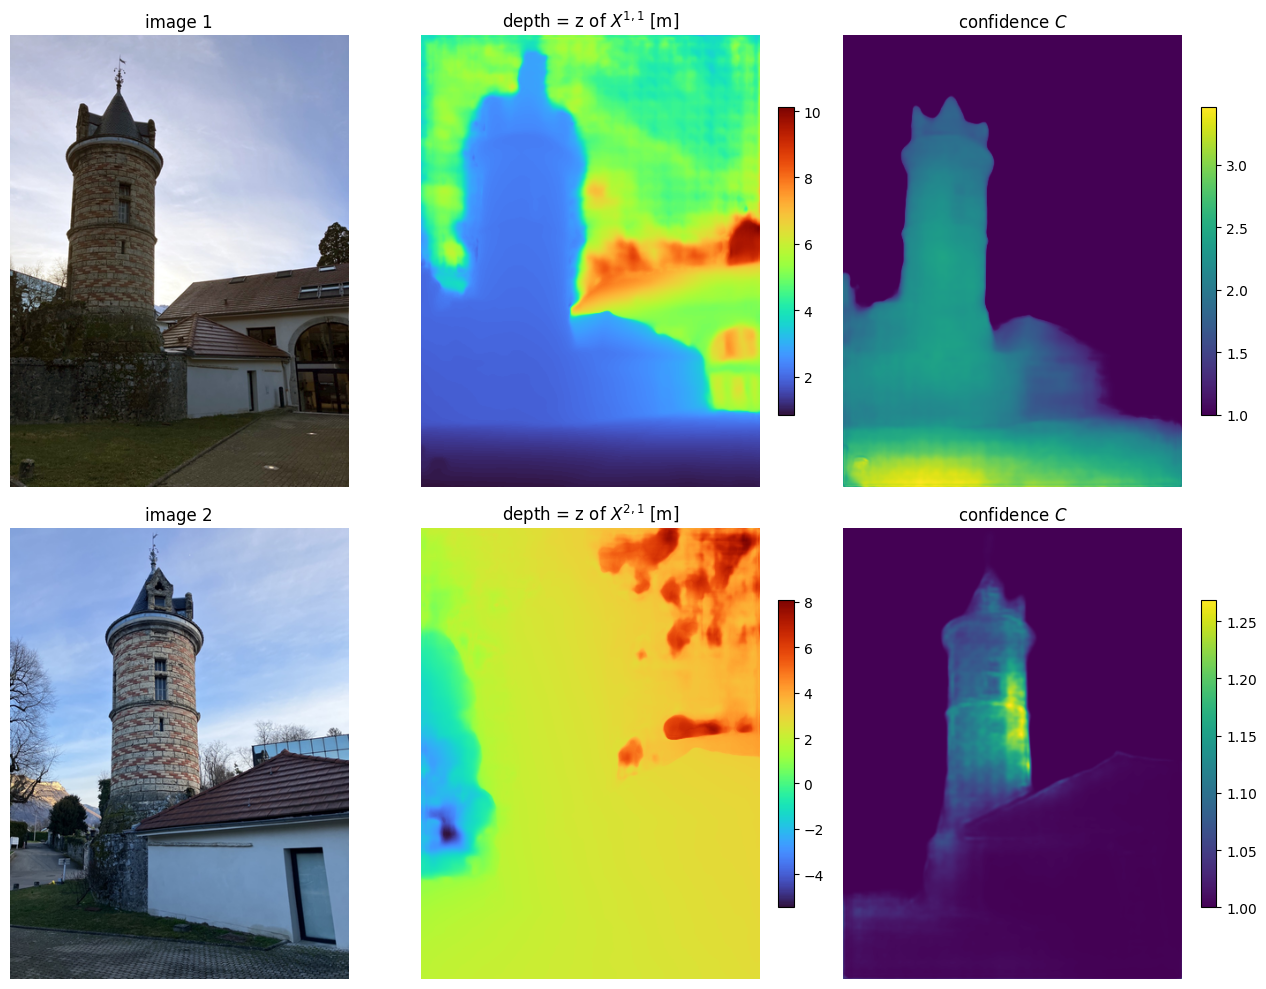

In [4]:
# pointmaps (H, W, 3) in camera-1 frame, confidences (H, W)
pts3d_1 = pred1["pts3d"].squeeze(0).detach().cpu().numpy()
pts3d_2 = pred2["pts3d_in_other_view"].squeeze(0).detach().cpu().numpy()
conf_1 = pred1["conf"].squeeze(0).detach().cpu().numpy()
conf_2 = pred2["conf"].squeeze(0).detach().cpu().numpy()

# un-normalize the network-resized RGB for display
rgb = [((im["img"].squeeze(0).permute(1, 2, 0).numpy() + 1) / 2) for im in images]
H, W = rgb[0].shape[:2]
print("pointmap shapes:", pts3d_1.shape, pts3d_2.shape)

fig, ax = plt.subplots(2, 3, figsize=(13, 10))
for r, (im, pts, cf) in enumerate([(rgb[0], pts3d_1, conf_1), (rgb[1], pts3d_2, conf_2)]):
    ax[r, 0].imshow(im);                     ax[r, 0].set_title(f"image {r+1}")
    d = ax[r, 1].imshow(pts[..., 2], cmap="turbo"); ax[r, 1].set_title(f"depth = z of $X^{{{r+1},1}}$ [m]")
    fig.colorbar(d, ax=ax[r, 1], fraction=0.04)
    c = ax[r, 2].imshow(cf, cmap="viridis");  ax[r, 2].set_title("confidence $C$")
    fig.colorbar(c, ax=ax[r, 2], fraction=0.04)
for a in ax.ravel(): a.axis("off")
plt.tight_layout()

Note what the confidence map does automatically: **sky, uniform walls, and
image borders get low confidence** — the network telling us where its 3D guess is
unreliable. We'll use it to filter the point cloud. Also note the depth is in
actual meters (this checkpoint is the *metric* MASt3R).

### 4.1 Matching — MASt3R's descriptor head

DUSt3R would match via reciprocal NN between the two *pointmaps in 3D*. MASt3R
matches its learned 24-dim *descriptors*. Here is what that means in detail.

**What a "descriptor" is here.** For every pixel MASt3R outputs a 24-dimensional,
L2-normalized vector $D_{u,v} \in \mathbb{S}^{23}$ (§2.3). It is produced by a small
MLP that reads the **concatenation of the encoder token and the decoder token** of
that patch (1024 + 768 = 1792-d), expands it to $25 \times 16^2$ channels and
`pixel_shuffle`s them back to per-pixel resolution. Two properties follow:

- The descriptor is **cross-view aware**. The decoder token has already attended to
  the other image, so the descriptor of a pixel in image 1 "knows" what image 2
  looks like. SIFT, SuperPoint, DISK and friends describe each image *blind*; this
  one cannot even be computed without the pair.
- It is **dense**. One descriptor per pixel — there is no keypoint detection stage
  at all, so there is no detector repeatability to lose on textureless surfaces.

**What the descriptors were trained to do.** Given ground-truth correspondences
$\hat{\mathcal{M}} = \{(i,j)\}$ (pixel $i$ of image 1 ↔ pixel $j$ of image 2),
MASt3R adds an InfoNCE cross-entropy term on top of the 3D regression loss
(`mast3r/losses.py::InfoNCE`, temperature $\tau = 0.07$, descriptors already unit
norm so the dot product is a cosine):

$$ s(i,j) = \exp\!\Big(\tfrac{1}{\tau}\, D^1_i \cdot D^2_j\Big), \qquad
\mathcal{L}_{\text{match}} = -\!\!\sum_{(i,j) \in \hat{\mathcal{M}}}\!\!
\Bigg[ \log \frac{s(i,j)}{\sum_{k} s(k,j)} \;+\; \log \frac{s(i,j)}{\sum_{k} s(i,k)} \Bigg]$$

Read the two terms as *"among all pixels of image 1, $i$ must win for $j$"* **and**
*"among all pixels of image 2, $j$ must win for $i$"*. This is a classification
problem over the whole image, not a metric-learning pull: it does not merely pull
true pairs together, it explicitly **pushes every other pixel away**. That is what
makes mutual nearest neighbours meaningful later.

It is also a deliberately *hard*, non-smooth objective. The 3D regression loss can
always be reduced by predicting a slightly blurred, averaged geometry; the InfoNCE
term cannot — a match is either the arg-max or it is not. That asymmetry is the
paper's argument for why matching deserves its own head instead of being read off
the pointmaps.

**Why not just match the pointmaps in 3D (what DUSt3R does)?** Because regression
is smooth by construction. On a flat wall the predicted 3D points vary slowly and
almost linearly, so the nearest neighbour of a given 3D point is ambiguous across a
large neighbourhood — accurate to a few pixels, never to sub-pixel. Descriptors
trained with the loss above are deliberately *peaky*. Same network, same forward
pass, but matches that are pixel-accurate instead of blurry — this is what took
MASt3R to the top of the map-free localization benchmark.

**Matching = reciprocal (mutual) nearest neighbours.** With
$\text{NN}_2(i) = \arg\max_j D^1_i \cdot D^2_j$ and symmetrically $\text{NN}_1(j)$,
the match set is the set of *mutual* winners:

$$\mathcal{M} = \big\{(i,j) \;:\; j = \text{NN}_2(i) \ \text{ and } \ i = \text{NN}_1(j)\big\}$$

Computing this by brute force means the full similarity matrix: at 512×384 that is
196,608 pixels per image, so $3.9 \times 10^{10}$ pairs — 155 GB in fp32. Not
happening.

**The trick** (`mast3r/fast_nn.py::fast_reciprocal_NNs`): a mutual pair is exactly a
**fixed point of the map $i \mapsto \text{NN}_1(\text{NN}_2(i))$**, and that map
converges in very few steps. So never build the matrix; iterate instead:

```
U ← every S-th pixel of image 1          # S = subsample_or_initxy1 = 8 → 48×64 = 3072 seeds
repeat (at most 10 times):
    V  ← NN₂(U)                          # each active seed in image 1 → its NN in image 2
    U' ← NN₁(V)                          # bounce back to image 1
    converged ← (U' == U)                # fixed point → (U, V) is a mutual pair
    freeze converged entries; keep iterating only on the rest
    U ← U'
```

Each iteration costs `n_active × 196k` dot products instead of `196k × 196k` — 64×
cheaper on the first pass, and cheaper still as entries freeze out. The `notyet`
boolean mask in the source is literally the "keep iterating only on the rest" line.

Note the seeds are a regular grid but the *matches* are not: a seed can migrate
several pixels before settling, and many seeds fall into the same basin of
attraction (hence the optional `ret_basin` output). What you get back is a few
thousand well-spread, mutually-consistent correspondences.

**Coarse-to-fine.** The network only ever sees 512-px inputs. For high-resolution
images MASt3R runs the pair once at low resolution, uses those coarse matches to
choose *overlapping crop pairs that actually see the same content*, re-runs the
network on each crop at native resolution, and maps the crop matches back onto the
original pixel grid. That is how a 512-px model produces high-res correspondences.

Now the run, on the 512-px pointmaps we already computed:

807 mutual matches


Text(0.5, 1.0, '40 of 807 reciprocal-NN descriptor matches')

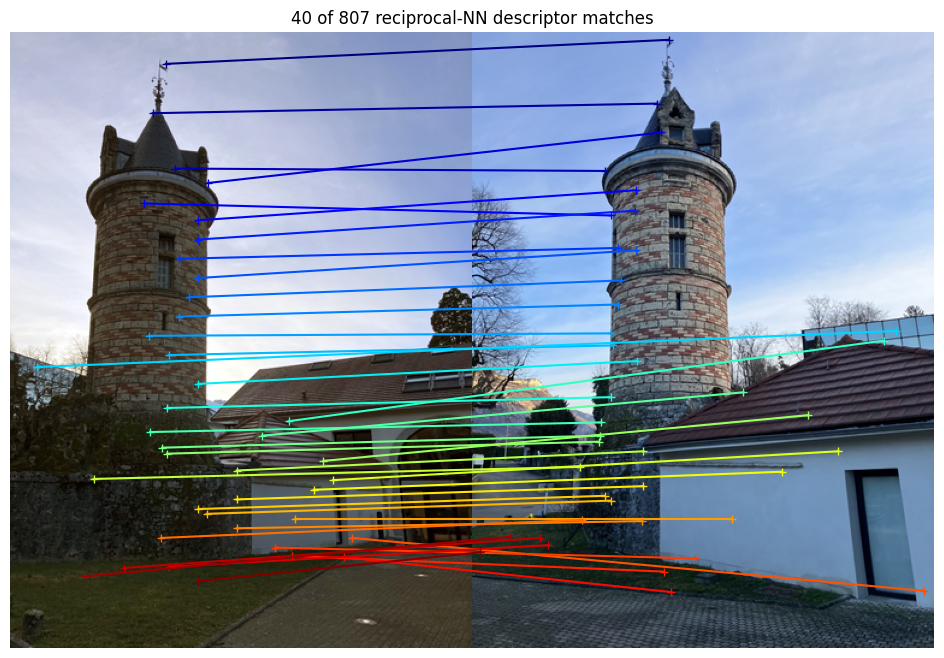

In [5]:
from mast3r.fast_nn import fast_reciprocal_NNs

desc1 = pred1["desc"].squeeze(0).detach()
desc2 = pred2["desc"].squeeze(0).detach()

# start from every 8th pixel, iterate NN until mutual convergence
matches_im1, matches_im2 = fast_reciprocal_NNs(
    desc1, desc2, subsample_or_initxy1=8, device=device, dist="dot", block_size=2**13)

# drop matches near the border
b = 3
ok = ((matches_im1[:, 0] >= b) & (matches_im1[:, 0] < W - b) &
      (matches_im1[:, 1] >= b) & (matches_im1[:, 1] < H - b) &
      (matches_im2[:, 0] >= b) & (matches_im2[:, 0] < W - b) &
      (matches_im2[:, 1] >= b) & (matches_im2[:, 1] < H - b))
matches_im1, matches_im2 = matches_im1[ok], matches_im2[ok]
print(f"{len(matches_im1)} mutual matches")

# visualize a subset
n_show = 40
idx = np.round(np.linspace(0, len(matches_im1) - 1, n_show)).astype(int)
canvas = np.concatenate([rgb[0], rgb[1]], axis=1)
plt.figure(figsize=(14, 8))
plt.imshow(canvas)
cmap = plt.get_cmap("jet")
for k, i in enumerate(idx):
    (x1, y1), (x2, y2) = matches_im1[i], matches_im2[i]
    plt.plot([x1, x2 + W], [y1, y2], "-+", color=cmap(k / (n_show - 1)), scalex=False, scaley=False)
plt.axis("off"); plt.title(f"{n_show} of {len(matches_im1)} reciprocal-NN descriptor matches")

No SIFT, no ratio test, no RANSAC over an essential matrix — and the matches
land on repetitive architecture and low-texture regions where classical features
struggle, because the descriptors were produced by a decoder that has already
*seen both images at once*.

### 4.2 Recovering intrinsics — the focal from a single pointmap

Since $X^{1,1}$ is in camera 1's frame, every point must satisfy the pinhole
projection with the (unknown) focal $f$. Estimate it with the Weiszfeld solver
from the paper:


In [6]:
from dust3r.post_process import estimate_focal_knowing_depth

pp = torch.tensor([W / 2, H / 2])  # principal point assumed at center
focal = float(estimate_focal_knowing_depth(
    pred1["pts3d"].detach().cpu(), pp, focal_mode="weiszfeld"))

K = np.array([[focal, 0, W / 2],
              [0, focal, H / 2],
              [0, 0, 1]])
print(f"estimated focal: {focal:.1f} px (at {W}x{H} resolution)")

estimated focal: 417.4 px (at 384x512 resolution)


### 4.3 Recovering the relative camera pose

**Camera 1 costs nothing**: the canonical frame *is* camera 1's frame, so
$R_1 = I,\ C_1 = 0$ by definition. The only unknown in a pair is camera 2.

**The free lunch.** Classical PnP needs 2D↔3D correspondences, and *obtaining* them
is the hard part (detect, match, triangulate, track). Here they are handed to us:
$X^{2,1}[u,v]$ is, by construction, the 3D point **in camera-1 coordinates** that
image 2 observes at **its own pixel** $(u,v)$. Every pixel of image 2 is therefore a
2D↔3D correspondence, and the array index *is* the correspondence — no matching
step involved at all (§4.1's matches are used elsewhere, e.g. the refinement in §5).

**What is being solved.** Find the rigid transform taking camera-1 coordinates into
camera 2 such that the predicted 3D points reproject onto the pixels they came from:

$$\min_{R,\,t}\ \sum_i \rho\Big( \big\lVert\, \pi\big(K\,(R\, X^{2,1}_i + t)\big) - (u_i, v_i) \,\big\rVert^2 \Big),
\qquad \pi(x,y,z) = \Big(\tfrac{x}{z},\ \tfrac{y}{z}\Big)$$

with $K$ from §4.2 and $\rho$ the RANSAC inlier test (`reprojectionError=3.0` px).
Six unknowns against thousands of equations — massively over-determined, which is
why it stays stable even though individual predicted points are noisy. Filtering by
confidence first (`conf > median`) removes sky and glass before RANSAC ever sees
them; the `[::20]` subsampling is only for speed.

**Conventions — this is where signs get lost.** OpenCV's `solvePnPRansac` returns
`rvec, tvec` describing the **world → camera** transform, and here *world = camera 1*:

$$ x_{c_2} = R_{2\leftarrow 1}\, x_{c_1} + t_{2\leftarrow 1} $$

What we want to draw in the canonical frame is the **pose of camera 2**, i.e. the
inverse of that:

$$ R_{\text{pose}} = R_{2\leftarrow 1}^{\top}, \qquad
   C_2 = -\,R_{2\leftarrow 1}^{\top}\, t_{2\leftarrow 1} $$

$C_2$ is camera 2's optical centre expressed in camera-1 coordinates — the
**baseline vector** — and $\lVert C_2 \rVert$ is the baseline length in metres for
this metric checkpoint. Those two formulas are exactly the lines `R = R_w2c.T` and
`t = -R_w2c.T @ tvec` in the cell below. The rotation angle printed is the geodesic
angle $\theta = \arccos\!\big(\frac{\operatorname{tr}(R) - 1}{2}\big)$, i.e. how far
apart the two viewing directions are.

**The alternative route (symmetric, and needs no intrinsics).** Run the network a
second time with the images swapped to obtain $X^{1,2}$ — image 1's pointmap
expressed in *camera 2's* frame. Now the same physical points exist in two frames,
so relative pose is a plain Procrustes / Umeyama problem with a closed-form
solution (wrapped in RANSAC for robustness):

$$\min_{\sigma,\,R,\,t}\ \sum_i C_i \big\lVert\, X^{1,1}_i - \sigma\,(R\, X^{1,2}_i + t) \,\big\rVert^2$$

This is the route DUSt3R's paper describes, and it never touches $K$. Its extra
unknown $\sigma$ is the scale ratio between the two runs; on a metric checkpoint
$\sigma \approx 1$, so it doubles as a free consistency check. The PnP route used
here needs only one forward pass and weights near points more sensibly (2D
reprojection error), which is usually the more accurate of the two.

**On scale.** With the *metric* checkpoint, $t$ is in metres and $\lVert C_2 \rVert$
is a real baseline you can compare against a tape measure. With an up-to-scale
checkpoint the pair is defined only up to one global scale factor — the classical
two-view ambiguity — and only the *direction* of $C_2$ carries information.

| | camera 1 | camera 2 |
|---|---|---|
| rotation in canonical frame | $I$ (by definition) | $R_{2\leftarrow1}^{\top}$ from PnP |
| centre in canonical frame | $0$ (by definition) | $-R_{2\leftarrow1}^{\top} t_{2\leftarrow1}$ |
| what supplies it | the frame convention itself | $X^{2,1}$ + pixel grid + $K$ |

In [7]:
import cv2

# 2D↔3D: pixels of image 2 ↔ their 3D points in camera-1 coordinates,
# subsampled and filtered by confidence
c2 = conf_2.ravel()
thr = np.quantile(c2, 0.5)
sel = np.where(c2 > thr)[0][::20]
uv = np.stack(np.meshgrid(np.arange(W), np.arange(H)), -1).reshape(-1, 2).astype(np.float64)
obj = pts3d_2.reshape(-1, 3).astype(np.float64)

ok, rvec, tvec, inliers = cv2.solvePnPRansac(
    obj[sel], uv[sel], K, None, flags=cv2.SOLVEPNP_SQPNP,
    iterationsCount=300, reprojectionError=3.0)

R_w2c, _ = cv2.Rodrigues(rvec)          # world(=cam1) -> cam2
R = R_w2c.T                             # cam2 pose in cam1 frame
t = (-R_w2c.T @ tvec).ravel()

angle = np.degrees(np.arccos(np.clip((np.trace(R) - 1) / 2, -1, 1)))
print(f"PnP inliers: {len(inliers)}/{len(sel)}")
print(f"camera 2 position in cam-1 frame [m]: {t.round(3)}")
print(f"rotation between the views: {angle:.1f} deg")
print("R =\n", R.round(3))

PnP inliers: 1190/4916
camera 2 position in cam-1 frame [m]: [1.762 0.637 2.424]
rotation between the views: 92.3 deg
R =
 [[-0.039 -0.228 -0.973]
 [ 0.281  0.932 -0.229]
 [ 0.959 -0.283  0.028]]


**Reading those numbers — and when not to trust them.**

- **Inlier ratio is the health check.** A high inlier count means the predicted
  $X^{2,1}$ is self-consistent with a *single* rigid camera motion. A poor ratio
  usually means the two views barely overlap, or the scene moved, or the focal from
  §4.2 is off — in that order of likelihood.
- **A bad focal biases the pose.** $K$ came from $X^{1,1}$ in §4.2 and is then held
  fixed inside PnP, so any error in $f$ leaks into $t$. In §5 the sparse global
  alignment re-estimates focals *and* poses jointly (`shared_intrinsics=True`),
  which is why its numbers are the ones to quote for a real reconstruction.
- **Degenerate configurations still return an answer.** Under near-pure rotation
  (baseline → 0) the translation direction is unobservable, but PnP will happily
  hand back a small, meaningless $t$ — there is no residual that flags it, because
  the network filled in the geometry from monocular priors (§2.3). Likewise for a
  dominantly planar scene. Sanity-check $\lVert C_2 \rVert$ against what you know
  about how far the camera actually moved.
- **The strongest end-to-end check** ties all three steps together: take the §4.1
  matches, look up their 3D points in $X^{1,1}$, project them into image 2 with
  $\pi(K(R_{2\leftarrow1} X + t_{2\leftarrow1}))$, and compare against
  `matches_im2`. Small residuals mean the descriptors, the focal, and the pose all
  agree. Running the pair a second time with the images swapped and comparing the
  Procrustes pose against this PnP pose is the other independent check.

### 4.4 The point cloud

Concatenate both pointmaps (they're in the same frame!), color by RGB, filter by
confidence, and export to PLY — open it in MeshLab / CloudCompare, or view the
scatter plot below.


200,507 points after confidence filtering
wrote /home/behnam/workspace/robotic_notes/docs/visual_odometry/output/mast3r_pair.ply


Text(0.5, 0.92, 'fused pointmaps + recovered cameras')

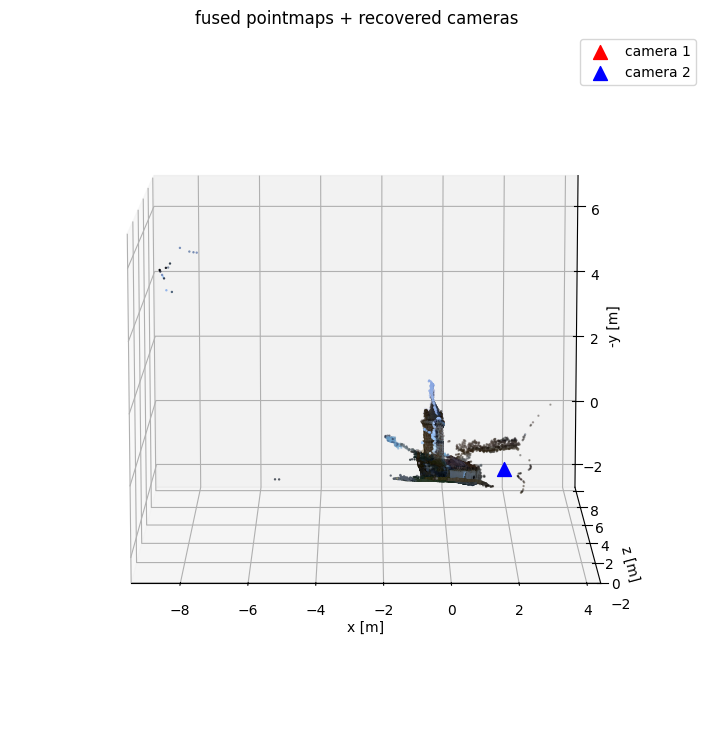

In [8]:
import trimesh

pts = np.concatenate([pts3d_1.reshape(-1, 3), pts3d_2.reshape(-1, 3)])
cols = np.concatenate([rgb[0].reshape(-1, 3), rgb[1].reshape(-1, 3)])
conf = np.concatenate([conf_1.ravel(), conf_2.ravel()])

mask = conf > np.quantile(conf, 0.3)          # drop the least confident 30%
pts, cols = pts[mask], cols[mask]
print(f"{len(pts):,} points after confidence filtering")

out = HERE / "output" / "mast3r_pair.ply"
out.parent.mkdir(exist_ok=True)
trimesh.PointCloud(pts, colors=(cols * 255).astype(np.uint8)).export(str(out))
print("wrote", out)

# quick 3D scatter (subsampled)
ss = np.random.default_rng(0).choice(len(pts), 40_000, replace=False)
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(projection="3d")
ax.scatter(pts[ss, 0], pts[ss, 2], -pts[ss, 1], c=cols[ss], s=0.5)
ax.scatter(*[[v] for v in [0, 0, 0]], c="r", marker="^", s=100, label="camera 1")
ax.scatter([t[0]], [t[2]], [-t[1]], c="b", marker="^", s=100, label="camera 2")
ax.set_xlabel("x [m]"); ax.set_ylabel("z [m]"); ax.set_zlabel("-y [m]")
ax.view_init(elev=10, azim=-90); ax.legend(); ax.set_title("fused pointmaps + recovered cameras")

### 4.5 Interactive visualization with Rerun

The matplotlib scatter is static; for real inspection we log everything to
[Rerun](https://rerun.io): the fused cloud, plus both cameras as pinhole frustums
with their images attached, at the recovered pose from §4.3. Open the file with

```bash
python -m rerun output/mast3r_pair.rrd     # from the same env (bundled viewer)
```


In [9]:
import rerun as rr

rr.init("mast3r_pair")
rrd_pair = HERE / "output" / "mast3r_pair.rrd"
rr.save(str(rrd_pair))

# DUSt3R/OpenCV camera convention: x right, y down, z forward
rr.log("world", rr.ViewCoordinates.RDF, static=True)
rr.log("world/points", rr.Points3D(pts, colors=(cols * 255).astype(np.uint8)))

# camera 1 = the reference frame (identity), camera 2 at the PnP-recovered pose
for name, Rc, tc, im in [("cam1", np.eye(3), np.zeros(3), rgb[0]),
                         ("cam2", R, t, rgb[1])]:
    rr.log(f"world/{name}", rr.Transform3D(translation=tc, mat3x3=Rc))
    rr.log(f"world/{name}/image", rr.Pinhole(focal_length=focal, width=W, height=H))
    rr.log(f"world/{name}/image", rr.Image((im * 255).astype(np.uint8)))

print("wrote", rrd_pair)

wrote /home/behnam/workspace/robotic_notes/docs/visual_odometry/output/mast3r_pair.rrd


## 5. From a pair to a scene: sparse global alignment (MASt3R-SfM style)

With more than two images, each pair lives in its own frame (§2.7). MASt3R ships
the sparse global alignment used by MASt3R-SfM: match all pairs, coarse-align in
3D, then refine with 2D reprojection error. This is the "mini bundle adjustment"
that stitches everything into one world frame — here on all 7 tower images:

In [10]:
from mast3r.cloud_opt.sparse_ga import sparse_global_alignment
from dust3r.image_pairs import make_pairs
import tempfile

all_files = [str(f) for f in files]
pairs = make_pairs(load_images(all_files, size=512),
                   scene_graph="complete", prefilter=None, symmetrize=True)

scene = sparse_global_alignment(
    all_files, pairs, tempfile.mkdtemp(), model,
    lr1=0.07, niter1=300, lr2=0.01, niter2=300,
    device=device, matching_conf_thr=5.0, shared_intrinsics=True)

poses = scene.get_im_poses().detach().cpu().numpy()      # cam-to-world, one per image
focals = scene.get_focals().detach().cpu().numpy().ravel()
print("optimized focals [px]:", focals.round(1))
print("camera centers [m]:\n", poses[:, :3, 3].round(2))

/home/behnam/workspace/robotic_notes/docs/visual_odometry/third_party/mast3r/dust3r/dust3r/cloud_opt/base_opt.py:275: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  @torch.cuda.amp.autocast(enabled=False)


>> Loading a list of 7 images
 - adding /home/behnam/workspace/robotic_notes/docs/visual_odometry/third_party/mast3r/assets/NLE_tower/01D90321-69C8-439F-B0B0-E87E7634741C-83120-000041DAE419D7AE.jpg with resolution 1000x1334 --> 384x512
 - adding /home/behnam/workspace/robotic_notes/docs/visual_odometry/third_party/mast3r/assets/NLE_tower/1AD85EF5-B651-4291-A5C0-7BDB7D966384-83120-000041DADF639E09.jpg with resolution 1000x1334 --> 384x512
 - adding /home/behnam/workspace/robotic_notes/docs/visual_odometry/third_party/mast3r/assets/NLE_tower/2679C386-1DC0-4443-81B5-93D7EDE4AB37-83120-000041DADB2EA917.jpg with resolution 1334x1000 --> 512x384
 - adding /home/behnam/workspace/robotic_notes/docs/visual_odometry/third_party/mast3r/assets/NLE_tower/28EDBB63-B9F9-42FB-AC86-4852A33ED71B-83120-000041DAF22407A1.jpg with resolution 1000x1334 --> 384x512
 - adding /home/behnam/workspace/robotic_notes/docs/visual_odometry/third_party/mast3r/assets/NLE_tower/91E9B685-7A7D-42D7-B933-23A800EE4129-83120

  0%|          | 0/42 [00:00<?, ?it/s]

/home/behnam/workspace/robotic_notes/docs/visual_odometry/third_party/mast3r/mast3r/cloud_opt/sparse_ga.py:620: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):


  2%|▏         | 1/42 [00:00<00:32,  1.27it/s]

...

 99%|█████████▉| 298/300 [00:05<00:00, 59.72it/s, lr=0.0000, loss=0.877]

100%|█████████▉| 299/300 [00:05<00:00, 59.72it/s, lr=0.0000, loss=0.877]

100%|██████████| 300/300 [00:05<00:00, 60.73it/s, lr=0.0000, loss=0.877]

100%|██████████| 300/300 [00:05<00:00, 56.29it/s, lr=0.0000, loss=0.877]

>> final loss = 0.8767885565757751
Final focal (shared) =  417.05
optimized focals [px]: [417. 417. 417. 417. 417. 417. 417.]
camera centers [m]:
 [[ 1.92  3.67 -2.83]
 [-3.39  3.83 -0.82]
 [-4.    0.25  9.8 ]
 [ 3.55  0.98  2.81]
 [-2.76  4.6  -3.25]
 [-2.46  4.04 -1.77]
 [-5.32  3.77  0.67]]


469,291 points in the fused scene
wrote /home/behnam/workspace/robotic_notes/docs/visual_odometry/output/mast3r_scene.ply


Text(0.5, 0.92, '7-image scene after sparse global alignment')

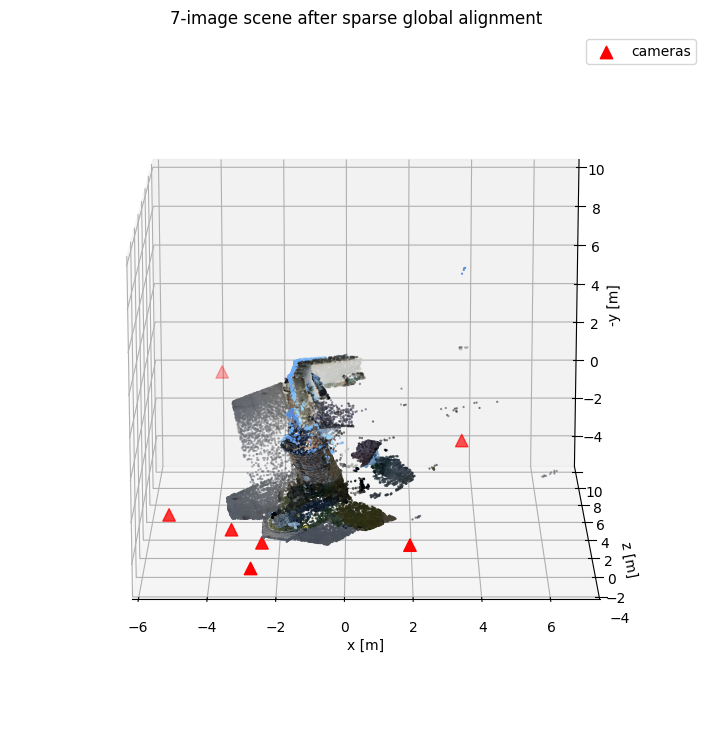

In [11]:
# fused scene cloud from the optimized depthmaps
pts3d_w, _, confs = scene.get_dense_pts3d(clean_depth=True)

all_pts, all_cols = [], []
for i, f in enumerate(all_files):
    p = pts3d_w[i].detach().cpu().numpy().reshape(-1, 3)
    c = confs[i].detach().cpu().numpy().ravel()
    im = load_images([f], size=512, verbose=False)[0]["img"]
    col = ((im.squeeze(0).permute(1, 2, 0).numpy() + 1) / 2).reshape(-1, 3)
    m = c > 1.5
    all_pts.append(p[m]); all_cols.append(col[m])
all_pts, all_cols = np.concatenate(all_pts), np.concatenate(all_cols)
print(f"{len(all_pts):,} points in the fused scene")

out = HERE / "output" / "mast3r_scene.ply"
trimesh.PointCloud(all_pts, colors=(all_cols * 255).astype(np.uint8)).export(str(out))
print("wrote", out)

ss = np.random.default_rng(0).choice(len(all_pts), 60_000, replace=False)
fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(projection="3d")
ax.scatter(all_pts[ss, 0], all_pts[ss, 2], -all_pts[ss, 1], c=all_cols[ss], s=0.4)
cams = poses[:, :3, 3]
ax.scatter(cams[:, 0], cams[:, 2], -cams[:, 1], c="r", marker="^", s=80, label="cameras")
ax.set_xlabel("x [m]"); ax.set_ylabel("z [m]"); ax.set_zlabel("-y [m]")
ax.view_init(elev=15, azim=-90); ax.legend(); ax.set_title("7-image scene after sparse global alignment")

And the same scene in Rerun — all 7 optimized camera poses with their images,
plus the fused cloud (`python -m rerun output/mast3r_scene.rrd`):


In [12]:
rr.init("mast3r_scene")
rrd_scene = HERE / "output" / "mast3r_scene.rrd"
rr.save(str(rrd_scene))

rr.log("world", rr.ViewCoordinates.RDF, static=True)
rr.log("world/points", rr.Points3D(all_pts, colors=(all_cols * 255).astype(np.uint8)))

for i, (pose, f) in enumerate(zip(poses, focals)):
    im = load_images([all_files[i]], size=512, verbose=False)[0]["img"]
    im = ((im.squeeze(0).permute(1, 2, 0).numpy() + 1) / 2 * 255).astype(np.uint8)
    rr.log(f"world/cam{i}", rr.Transform3D(translation=pose[:3, 3], mat3x3=pose[:3, :3]))
    rr.log(f"world/cam{i}/image", rr.Pinhole(focal_length=float(f), width=W, height=H))
    rr.log(f"world/cam{i}/image", rr.Image(im))

print("wrote", rrd_scene)

wrote /home/behnam/workspace/robotic_notes/docs/visual_odometry/output/mast3r_scene.rrd


## 6. Summary — the corrected mental model

1. A **pointmap** maps every pixel to an $(x,y,z)$ — richer than a depth map,
   intrinsics included implicitly. The head does not emit the point directly: it
   emits a raw 3-vector that is decoded as *unit ray direction* × `expm1(‖·‖)`,
   i.e. a bearing and a strictly-positive range (§2.3).
2. DUSt3R processes the pair **jointly**; cross-attention between the two decoders
   is where correspondence happens. Both output pointmaps are expressed **in
   camera 1's frame** — the "canonical frame" is nothing more mysterious than that,
   and it is enforced only by the training targets, never by a geometric constraint.
3. Within a pair there is **no ICP / no explicit registration** — the network
   outputs already-aligned clouds. Across pairs, **global alignment** (3D distance
   minimization, not reprojection BA) stitches everything into one world frame.
4. **Matching:** DUSt3R → reciprocal NN in 3D pointmap space; MASt3R → reciprocal
   NN over its learned, L2-normalized 24-dim descriptors, trained with a two-sided
   InfoNCE loss and searched by fixed-point iteration of $\text{NN}_1 \circ \text{NN}_2$
   rather than a full similarity matrix (§4.1). No epipolar geometry anywhere.
5. **Poses:** camera 1 is the identity *by definition*; camera 2 comes from
   PnP-RANSAC on $X^{2,1}$ (its pixels are 2D↔3D pairs for free), or from Procrustes
   between $X^{1,1}$ and the swapped-pair $X^{1,2}$ if you'd rather not need $K$.
   Intrinsics (Weiszfeld on $X^{1,1}$) and depth ($z$ channel) are likewise
   *by-products* of the pointmaps.
6. **Depth Anything** is a separate monocular lineage, not a component of DUSt3R;
   **VGGT** replaces pairwise+alignment with one N-view transformer;
   **MapAnything / Depth Anything 3** are where the lineages converge.

**Files this notebook produced:**

- `output/mast3r_pair.ply`, `output/mast3r_scene.ply` — MeshLab / CloudCompare
- `output/mast3r_pair.rrd`, `output/mast3r_scene.rrd` — `python -m rerun <file>`

For a two-image run outside Jupyter there is a companion script:
`scripts/mast3r_two_images.py img1.jpg img2.jpg --rerun` (spawns the Rerun viewer
directly).